In [47]:
import cmdstanpy

# Point CmdStanPy at your existing local CmdStan build.
# Alternative: set a CMDSTAN environment variable and delete this line,
# to keep the machine-specific path out of committed code.
cmdstanpy.set_cmdstan_path("/Users/marobinette/cmdstan")

print("cmdstanpy", cmdstanpy.__version__)
print("cmdstan", ".".join(map(str, cmdstanpy.cmdstan_version())))

cmdstanpy 1.3.0
cmdstan 2.40


In [48]:
import numpy as np
from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file="./stan_code/uniform_prior_predictive.stan")

plausible_data = {
    "N": 5068,
    "mu_lo": 0,
    "mu_hi": 2700,
    "sigma_hi": 1000,
}
# -----------------------------------------------------------------------------

plausible_fit = model.sample(
    data=plausible_data,
    fixed_param=True,     # nothing to sample; just run the RNG in generated quantities
    chains=1,
    iter_sampling=50,     # 50 simulated datasets, like the height example
    seed=1,
)

sims = plausible_fit.stan_variable("elo_sim")   # shape (50, 5068)
print("simulated datasets:", sims.shape)
print(f"fraction below the 600 floor : {np.mean(sims < 600):.3f}")
print(f"fraction below 0 (impossible): {np.mean(sims < 0):.3f}")
print(f"fraction above 4000          : {np.mean(sims > 4000):.3f}")

# Next move when you want to see it: histogram one or all of the datasets,
# e.g. matplotlib hist of sims.ravel(), and drop vertical lines at 600 and 0.

20:55:15 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1050 [00:00<?, ?it/s, (Warmup)]

20:55:16 - cmdstanpy - INFO - CmdStan done processing.



simulated datasets: (50, 5068)
fraction below the 600 floor : 0.196
fraction below 0 (impossible): 0.063
fraction above 4000          : 0.002


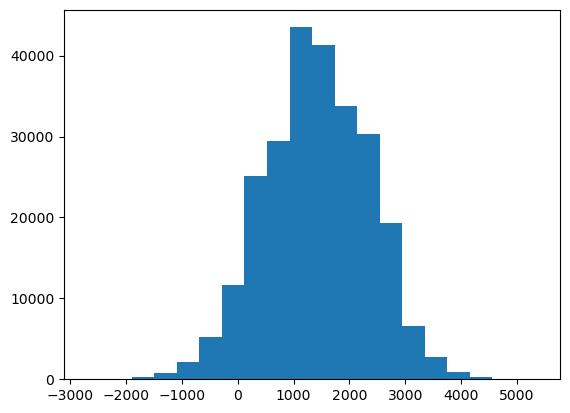

In [49]:
import matplotlib.pyplot as plt
plausible_elo_sim = plausible_fit.stan_variable("elo_sim")
plt.hist(plausible_elo_sim.ravel(), bins=20)
plt.savefig("figures/prior_predictive_hist.png", dpi=300)


In [50]:
data = {
    "N": 5068,
    "mu_lo": 800,
    "mu_hi": 1600,
    "sigma_hi": 300,
}
# -----------------------------------------------------------------------------

fit = model.sample(
    data=data,
    fixed_param=True,     # nothing to sample; just run the RNG in generated quantities
    chains=1,
    iter_sampling=50,     # 50 simulated datasets, like the height example
    seed=1,
)

sims = fit.stan_variable("elo_sim")   # shape (50, 5068)
print("simulated datasets:", sims.shape)
print(f"fraction below the 600 floor : {np.mean(sims < 600):.3f}")
print(f"fraction below 0 (impossible): {np.mean(sims < 0):.3f}")
print(f"fraction above 3000          : {np.mean(sims > 3000):.3f}")


20:55:16 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1050 [00:00<?, ?it/s, (Warmup)]

20:55:16 - cmdstanpy - INFO - CmdStan done processing.



simulated datasets: (50, 5068)
fraction below the 600 floor : 0.014
fraction below 0 (impossible): 0.000
fraction above 3000          : 0.000


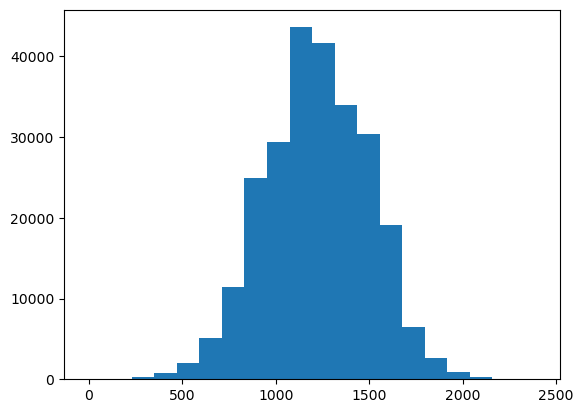

In [51]:
fit_elo_sim = fit.stan_variable("elo_sim")
plt.hist(fit_elo_sim.ravel(), bins=20)
plt.savefig("figures/proper_prior_predictive_hist.png", dpi=300)


In [52]:
normal_model = CmdStanModel(stan_file="./stan_code/normal_prior_predictive.stan")

normal_data = {
    "N": 5068,
    "mu_mean": 1300,
    "mu_sd": 300,
    "sigma_hi": 500,
}
# -----------------------------------------------------------------------------

normal_fit = normal_model.sample(
    data=normal_data,
    fixed_param=True,     # nothing to sample; just run the RNG in generated quantities
    chains=1,
    iter_sampling=50,     # 50 simulated datasets, like the height example
    seed=1,
)

sims = normal_fit.stan_variable("elo_sim")   # shape (50, 5068)
print("simulated datasets:", sims.shape)
print(f"fraction below the 600 floor : {np.mean(sims < 600):.3f}")
print(f"fraction below 0 (impossible): {np.mean(sims < 0):.3f}")
print(f"fraction above 3000          : {np.mean(sims > 3000):.3f}")


20:55:17 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1050 [00:00<?, ?it/s, (Warmup)]

20:55:17 - cmdstanpy - INFO - CmdStan done processing.



simulated datasets: (50, 5068)
fraction below the 600 floor : 0.050
fraction below 0 (impossible): 0.001
fraction above 3000          : 0.000


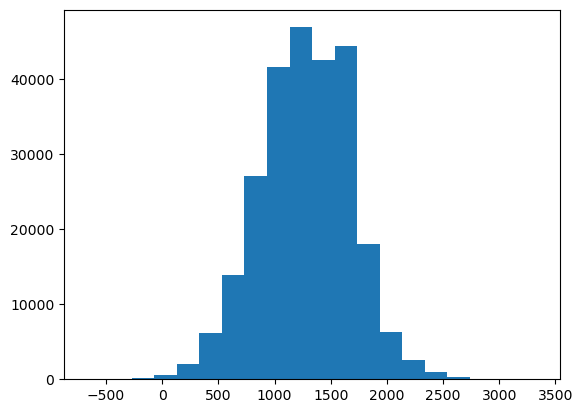

In [54]:
normal_fit_elo_sim = normal_fit.stan_variable("elo_sim")
plt.hist(normal_fit_elo_sim.ravel(), bins=20)
plt.savefig("figures/normal_prior_predictive_hist.png", dpi=300)
